### Predicción de Precios de Vehículos Usados (Core)
#### Implementar y evaluar modelos de regresión, y seleccionar el mejor modelo basado en las métricas de evaluación.

#### Requisitos

- 1 Carga y Exploración de Datos:



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

- 1.1. Descargar y cargar el dataset.


In [3]:
# Cargar el archivo CSV
df = pd.read_csv('./data/vehicles.csv')

- 1.2. Realizar una exploración inicial para entender la estructura del dataset.


In [4]:


# mostrar los primeros 10 registros
display("primeros 10 registros : ",df.head(10))

# los ultimos 5 registros
display("ultimos 5 registros : ",df.tail())

# informacion general del dataframe:
print("informacion general del dataframe : ",df.info())

# informacion estadisticas del dataframe :
display("informacion estadisticas del dataframe : ")
df.describe()


'primeros 10 registros : '

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
5,7222379453,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
6,7221952215,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
7,7220195662,https://hudsonvalley.craigslist.org/cto/d/poug...,hudson valley,https://hudsonvalley.craigslist.org,15995,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
8,7209064557,https://medford.craigslist.org/cto/d/grants-pa...,medford-ashland,https://medford.craigslist.org,5000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,or,NaN,NaN,NaN
9,7219485069,https://erie.craigslist.org/cto/d/erie-2012-su...,erie,https://erie.craigslist.org,3000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,pa,NaN,NaN,NaN


'ultimos 5 registros : '

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

'informacion estadisticas del dataframe : '

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


- 1.3. Identificar valores faltantes, duplicados y outliers.

In [5]:
print(" - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).")

for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")


 - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
• id                   -> 426880 únicos
  Lista de Valores :   [7222695916 7218891961 7221797935 ... 7301591147 7301591140 7301591129]

• url                  -> 426880 únicos
  Lista de Valores :   ['https://prescott.craigslist.org/cto/d/prescott-2010-ford-ranger/7222695916.html'
 'https://fayar.craigslist.org/ctd/d/bentonville-2017-hyundai-elantra-se/7218891961.html'
 'https://keys.craigslist.org/cto/d/summerland-key-2005-excursion/7221797935.html'
 ...
 'https://wyoming.craigslist.org/ctd/d/atlanta-2020-caddy-cadillac-xt4-sport/7301591147.html'
 'https://wyoming.craigslist.org/ctd/d/atlanta-2018-lexus-es-es-350-sedan-4d/7301591140.html'
 'https://wyoming.craigslist.org/ctd/d/atlanta-2019-bmw-series-430i-gran-coupe/7301591129.html']

• region               -> 404 únicos
  Lista de Valores :   ['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudso

In [6]:
#estructura del dataframe 
diccionario = {
    'id': 'int64',
    'url': 'str',
    'region': 'str',
    'region_url': 'str',
    'price': 'float64',      
    'year': 'int64',    
    'manufacturer': 'str',
    'model': 'str',
    'condition': 'str',
    'cylinders': 'str',   
    'fuel': 'str',
    'odometer': 'float64',
    'title_status': 'str',
    'transmission': 'str',
    'VIN': 'str',
    'drive': 'str',   
    'size': 'str',  
    'type': 'str',
    'paint_color': 'str',
    'image_url': 'str',
    'description': 'str',
    'county': 'str',
    'state': 'str',
    'lat': 'float64',
    'long': 'float64',
    'posting_date': 'str'  # Fecha de publicación
}

# transformamos a los tipos correctos cada columna deacuerdo al diccionario de datos
df = df.astype(diccionario, errors='ignore')
print("verificacion de las columnas Transformadas deacuerdo al diccionario : \n",df.dtypes)







verificacion de las columnas Transformadas deacuerdo al diccionario : 
 id                int64
url              object
region           object
region_url       object
price           float64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county           object
state            object
lat             float64
long            float64
posting_date     object
dtype: object


In [7]:
# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
print("\nDatos nulos totales : ", df.isnull().sum().sum())

valores_unicos = df["year"].unique()
print(f"• {col:20} -> {len(valores_unicos)} únicos")
print(f"  Lista de Valores :   {valores_unicos}\n")


Datos nulos por columna : 

id                 0
url                0
region             0
region_url         0
price              0
year            1205
manufacturer       0
model              0
condition          0
cylinders          0
fuel               0
odometer        4400
title_status       0
transmission       0
VIN                0
drive              0
size               0
type               0
paint_color        0
image_url          0
description        0
county             0
state              0
lat             6549
long            6549
posting_date       0
dtype: int64

Datos nulos totales :  18703
• posting_date         -> 115 únicos
  Lista de Valores :   [  nan 2014. 2010. 2020. 2017. 2013. 2012. 2016. 2019. 2011. 1992. 2018.
 2004. 2015. 2001. 2006. 1968. 2003. 2008. 2007. 2005. 1966. 2009. 1998.
 2002. 1999. 2021. 1997. 1976. 1969. 1995. 1978. 1954. 1979. 1970. 1974.
 1996. 1987. 2000. 1955. 1960. 1991. 1972. 1988. 1994. 1929. 1984. 1986.
 1989. 1973. 1946. 1933. 1958.

In [8]:


# verificar datos duplicados en el dataframe    
print("\n verificar datos duplicados en el dataframe.\n")
if df.duplicated().sum() == 0 :
    print("no se encontraron valores duplicados en el dataframe.")

   




 verificar datos duplicados en el dataframe.

no se encontraron valores duplicados en el dataframe.


In [9]:
# deteccion de outliarns en el dataframe
print("\n deteccion de outliarns en el dataframe.\n")
# columnas numericas
colum_numericas = [col for col in df if df[col].dtype in ['int64', 'float64']]

print("\n columnas numericas : ", colum_numericas)

# columnas categoricas
colum_categoricas = [col for col in df if df[col].dtype == 'object']

print("\n columnas categoricas :  ", colum_categoricas, "\n")

def deteccion_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    outliers = df_e[(df_e[column] < limit_inf) | (df_e[column] > limit_sup)]
    return outliers, limit_inf, limit_sup

def remover_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    df_out = df_e[(df_e[column] >= limit_inf) & (df_e[column] <= limit_sup)]
    return df_out

def mostrar_correccion_outliers(df_lim, column, arr_outliers):
   # print("arr_outliers", arr_outliers[column])

    existe = any(arr== column for arr in arr_outliers)
    #print("existe : ", existe)
    if existe: 
        outliers = df_lim[(df_lim[column] < arr_outliers[column]['lower']) | (df_lim[column] > arr_outliers[column]['upper'])]
 #       print(f"outliers {df_lim[column]} " )
 #       display("mostrar outliers", outliers)
        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        print(f"{column:18} -> cantidad de outliers = {count:3} | limites : [{arr_outliers[column]['lower']:,.2f}, {arr_outliers[column]['upper']:,.2f}]")

arr_outliers = {}

for col in colum_numericas:
        outliers, lower, upper = deteccion_outliers(df, col)
        # Guardas los valores

        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        if count > 0:
            print(f"{col:18} -> cantidad de outliers = {count:3} | limites : [{lower:,.2f}, {upper:,.2f}]")
            nombre_outlier = col
            arr_outliers.update({nombre_outlier: {'upper': upper, 'lower': lower}})
          


 deteccion de outliarns en el dataframe.


 columnas numericas :  ['id', 'price', 'year', 'odometer', 'lat', 'long']

 columnas categoricas :   ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'posting_date'] 

id                 -> cantidad de outliers =  44 | limites : [7,297,478,032.88, 7,325,918,849.88]
price              -> cantidad de outliers = 8177 | limites : [-24,978.62, 57,364.38]
year               -> cantidad de outliers = 15896 | limites : [1,994.50, 2,030.50]
odometer           -> cantidad de outliers = 4385 | limites : [-106,053.75, 277,300.25]
lat                -> cantidad de outliers = 6413 | limites : [22.91, 54.09]
long               -> cantidad de outliers = 195 | limites : [-158.60, -34.17]


In [10]:

# estandarizar columna year vienen datos tipo datatime 
# columna model tiene datos como #?NOMBRE y vacios, se estandariza a desconocido
# columna condition tiene datos vacios, se estandariza a desconocido
# columna cylinders tiene datos vacios, se estandariza a desconocido
# columna fuel tiene datos vacios, se estandariza a desconocido
# columna odometer tiene datos vacios, se estandariza a 0
# columna title_status tiene datos vacios, se estandariza a desconocido
# columna transmission tiene datos vacios, se estandariza a desconocido
# columna VIN tiene datos vacios, se estandariza a desconocido 
# columna drive tiene datos vacios, se estandariza a desconocido
# columan size tiene datos vacios, se estandariza a desconocido
# columna type tiene datos vacios, se estandariza a desconocido
# columna paint_color tiene datos vacios, se estandariza a desconocido
# columna image_url tiene datos vacios, se estandariza a desconocido
# columna description tiene datos vacios, se estandariza a desconocido
# columna county tiene datos vacios, se estandariza a desconocido
# columna state tiene datos vacios, se estandariza a desconocido
# columna lat tiene datos vacios, se estandariza a 0
# columna long tiene datos vacios, se estandariza a 0
# columna posting_date tiene datos vacios, se estandariza a desconocido

# reemplazar valores faltantes en columnas numericas con la media de cada columna pero en columnas 
# odometer, lat y long se reemplaza por 0

df_clean = df.copy()
for col in colum_numericas:
    if col in df_clean:
        if col in ['id', 'lat', 'long']:
            df_clean[col] = df_clean[col].fillna(0)
            print(f"   → {col}: imputado con 0")
        else:    
            mean_val = df_clean[col].mean()
            df_clean[col] = df_clean[col].fillna(mean_val)
            print(f"   → {col}: imputado con media ({mean_val:.2f})")

for col in colum_numericas:
    if col in df_clean: 
        df_clean[col] = df_clean[col].fillna(0)

for col in colum_categoricas:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(lambda x: 'desconocido' if pd.isna(x) or x == np.nan or str(x).lower() == 'nan' else x)
    

# elimnar duplicados en el dataframe

if df_clean.duplicated().sum() > 0 :
    print("\nDuplicados totales  = ", df_clean.duplicated().sum() , "; se realiza drop ")
    df_clean = df_clean.drop_duplicates()
    print("Duplicados totales despues del drop :", df_clean.duplicated().sum())
    display(df_clean) 

#display("dataframe limpio sin nulos : ", df_clean)

# corregir inconsistencia de las columnas categoricas 
print("\nCorrigiendo inconsistencias categóricas...")

# Ejemplos comunes en este dataset
df_clean['manufacturer'] = df_clean['manufacturer'].str.lower().str.strip()
df_clean['fuel'] = df_clean['fuel'].str.lower().str.strip()
df_clean['condition'] = df_clean['condition'].str.lower().str.strip()


# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df_clean.isnull().sum())
print("\nDatos nulos totales : ", df_clean.isnull().sum().sum())


for col in colum_numericas:            
    df_clean = remover_outliers(df_clean, col)



print("\n mostrar corrección de outlierns. \n ")
#display('df_limpio',df_limpio['length'])
#display(arr_outliers)
for col in colum_numericas:
     #print(f"columna : {col} ")
     mostrar_correccion_outliers(df_clean, col, arr_outliers)



df_2 = df_clean.copy()


   → id: imputado con 0
   → price: imputado con media (75199.03)
   → year: imputado con media (2011.24)
   → odometer: imputado con media (98043.33)
   → lat: imputado con 0
   → long: imputado con 0

Corrigiendo inconsistencias categóricas...

Datos nulos por columna : 

id              0
url             0
region          0
region_url      0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
VIN             0
drive           0
size            0
type            0
paint_color     0
image_url       0
description     0
county          0
state           0
lat             0
long            0
posting_date    0
dtype: int64

Datos nulos totales :  0

 mostrar corrección de outlierns. 
 
id                 -> cantidad de outliers =   0 | limites : [7,297,478,032.88, 7,325,918,849.88]
price              -> cantidad de outliers =   0 | limites : [-24,978.62, 57,364.3

In [11]:
mm_scaler = MinMaxScaler()

df_mm = df_clean.copy()
df_mm[colum_numericas] = mm_scaler.fit_transform(df_clean[colum_numericas])

print(df_mm[colum_numericas].describe().round(4))

display("dataframe normalizado con minmax : ", df_mm)

                id        price         year     odometer          lat  \
count  386861.0000  386861.0000  386861.0000  386861.0000  386861.0000   
mean        0.6370       0.2892       0.6503       0.3324       0.5266   
std         0.2829       0.2298       0.2009       0.2174       0.1731   
min         0.0000       0.0000       0.0000       0.0000       0.0000   
25%         0.4180       0.1043       0.5185       0.1440       0.4061   
50%         0.7056       0.2424       0.7037       0.3217       0.5505   
75%         0.8803       0.4533       0.8148       0.4846       0.6558   
max         1.0000       1.0000       1.0000       1.0000       1.0000   

              long  
count  386861.0000  
mean        0.5914  
std         0.2591  
min         0.0000  
25%         0.3384  
50%         0.6801  
75%         0.7917  
max         1.0000  


'dataframe normalizado con minmax : '

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
27,0.981557,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,0.585794,0.703704,gmc,sierra 1500 crew cab slt,good,8 cylinders,...,desconocido,pickup,white,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,desconocido,al,0.332835,0.716941,2021-05-04T12:31:18-0500
28,0.981549,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,0.393959,0.555556,chevrolet,silverado 1500,good,8 cylinders,...,desconocido,pickup,blue,https://images.craigslist.org/00R0R_lwWjXSEWNa...,Carvana is the safer way to buy a car During t...,desconocido,al,0.332835,0.716941,2021-05-04T12:31:08-0500
29,0.981563,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,0.690431,0.925926,chevrolet,silverado 1500 crew,good,8 cylinders,...,desconocido,pickup,red,https://images.craigslist.org/01212_jjirIWa0y0...,Carvana is the safer way to buy a car During t...,desconocido,al,0.332835,0.716941,2021-05-04T12:31:25-0500
30,0.976952,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,0.540451,0.814815,toyota,tundra double cab sr,good,8 cylinders,...,desconocido,pickup,red,https://images.craigslist.org/00x0x_1y9kIOzGCF...,Carvana is the safer way to buy a car During t...,desconocido,al,0.332835,0.716941,2021-05-04T10:41:31-0500
31,0.952012,https://auburn.craigslist.org/cto/d/auburn-uni...,auburn,https://auburn.craigslist.org,0.261593,0.666667,ford,f-150 xlt,excellent,6 cylinders,...,full-size,truck,black,https://images.craigslist.org/00404_l4loxHvdQe...,2013 F-150 XLT V6 4 Door. Good condition. Leve...,desconocido,al,0.332902,0.716341,2021-05-03T14:02:03-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,0.000507,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,0.411398,0.888889,nissan,maxima s sedan 4d,good,6 cylinders,...,desconocido,sedan,desconocido,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,desconocido,wy,0.372497,0.732912,2021-04-04T03:21:31-0600
426876,0.000507,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,0.533475,0.925926,volvo,s60 t5 momentum sedan 4d,good,desconocido,...,desconocido,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,desconocido,wy,0.372497,0.732912,2021-04-04T03:21:29-0600
426877,0.000504,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,0.610209,0.925926,cadillac,xt4 sport suv 4d,good,desconocido,...,desconocido,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,desconocido,wy,0.372256,0.733431,2021-04-04T03:21:17-0600
426878,0.000504,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,0.505572,0.851852,lexus,es 350 sedan 4d,good,6 cylinders,...,desconocido,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,desconocido,wy,0.372497,0.732912,2021-04-04T03:21:11-0600


### 3. Exploración de Datos:


- Crear visualizaciones univariadas y multivariadas.

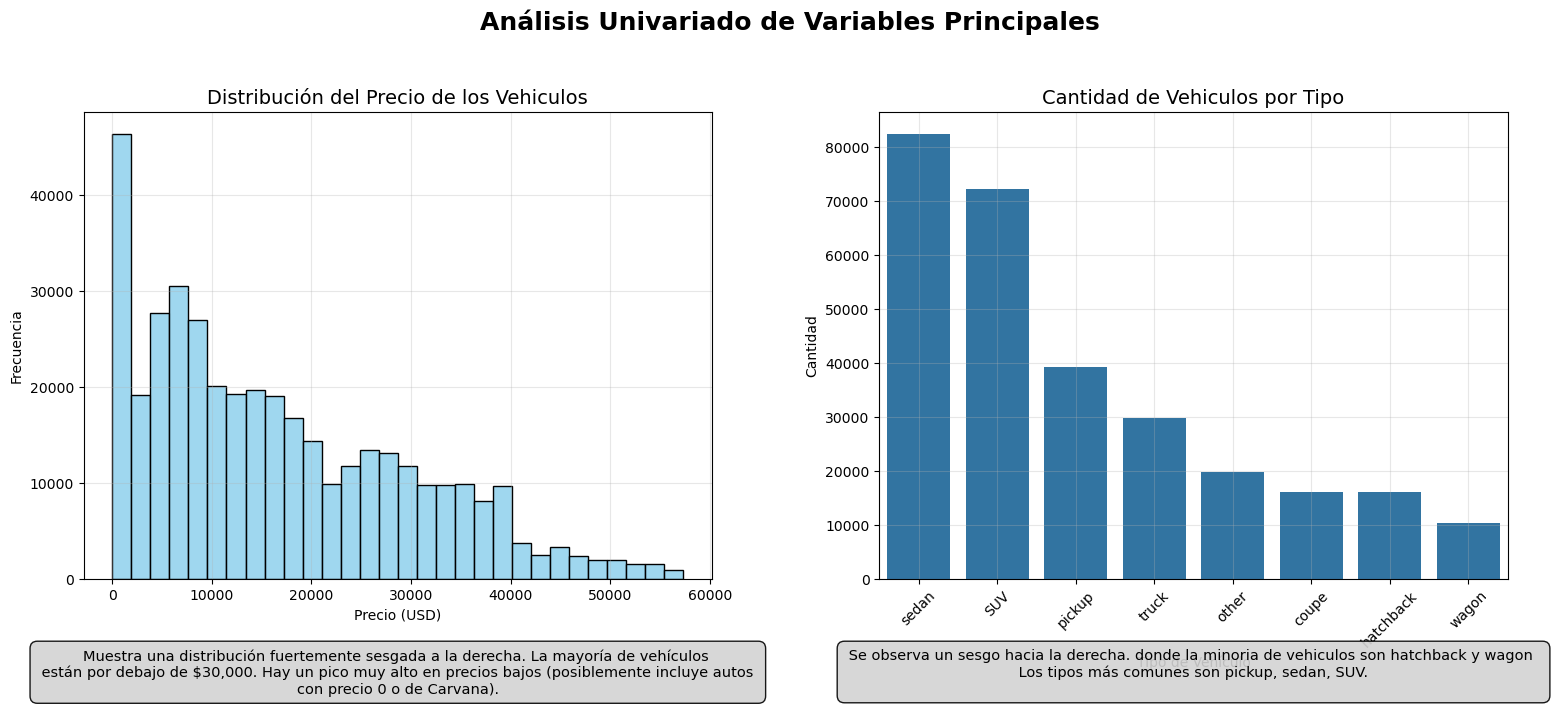

In [12]:
# # ====================== VISUALIZACIONES UNIVARIADAS ======================
# fig = plt.figure(figsize=(16, 12))
# fig.suptitle('Análisis Univariado de Variables Principales', fontsize=16, fontweight='bold')

# # 1. Histograma de Precio
# ax1 = plt.subplot(2, 2, 1)
# sns.histplot(data=df_2, x='price', bins=30, color='skyblue', edgecolor='black', alpha=0.8)
# ax1.set_title('Distribución de Precios')
# ax1.set_xlabel('Precio (USD)')
# ax1.set_ylabel('Conteo')
# ax1.grid(True, alpha=0.3)

# # 2. Histograma de Año
# ax2 = plt.subplot(2, 2, 2)
# sns.histplot(data=df_2, x='year', bins=30, color='skyblue', edgecolor='black', alpha=0.8)
# ax2.set_title('Distribución por Año del Vehículo')
# ax2.set_xlabel('Año')
# ax2.set_ylabel('Conteo')    
# ax2.grid(True, alpha=0.3)


# # 3. Boxplot de Precio
# ax3 = plt.subplot(2, 2, 3)
# sns.boxplot(data=df_2, y='price', ax=ax3)
# ax3.set_title('Boxplot de Precios')
# # ax3.set_ylim(0, df_2['price'].quantile(0.95))
# plt.xlabel('Precios')
# plt.ylabel('Pagos Mensuales ')


# # 4. Countplot de Tipo de Vehículo
# ax4 = plt.subplot(2, 2, 4)
# top_types = df_2['type'].value_counts().head(10)
# sns.countplot(data=df_2[df_2['type'].isin(top_types.index)], 
#               y='type', order=top_types.index, ax=ax4)
# ax4.set_title('Top 10 Tipos de Vehículos')



# fig1, axes1 = plt.subplots(2, 3, figsize=(20, 12))
# fig1.suptitle('Análisis Univariado - Distribución de Variables', fontsize=18, fontweight='bold')

# # 1. Histograma de Precio
# sns.histplot(data=df_2, x='price', bins=50, kde=True, ax=axes1[0,0])
# axes1[0,0].set_title('Distribución de Precios', fontsize=14)
# axes1[0,0].set_xlabel('Precio (USD)')
# axes1[0,0].set_ylabel('Frecuencia')
# axes1[0,0].text(0.95, 0.95, 'La mayoría de vehículos están entre\n$5,000 y $35,000', 
#                 transform=axes1[0,0].transAxes, ha='right', va='top', bbox=dict(boxstyle="round", facecolor="wheat"))

# # 2. Boxplot de Precio
# sns.boxplot(data=df_2, y='price', ax=axes1[0,1])
# axes1[0,1].set_title('Boxplot de Precios', fontsize=14)
# axes1[0,1].set_ylabel('Precio (USD)')
# axes1[0,1].text(0.05, 0.95, 'Alta dispersión y muchos outliers\n(precios muy altos)', 
#                 transform=axes1[0,1].transAxes, bbox=dict(boxstyle="round", facecolor="lightblue"))

# # 3. Histograma de Año
# sns.histplot(data=df_2, x='year', bins=30, kde=True, ax=axes1[0,2])
# axes1[0,2].set_title('Distribución por Año del Vehículo', fontsize=14)
# axes1[0,2].set_xlabel('Año')
# axes1[0,2].set_ylabel('Cantidad')

# # 4. Countplot - Tipo de Combustible
# sns.countplot(data=df_2, x='fuel', order=df_2['fuel'].value_counts().index, ax=axes1[1,0])
# axes1[1,0].set_title('Distribución por Tipo de Combustible', fontsize=14)
# axes1[1,0].tick_params(axis='x', rotation=45)
# axes1[1,0].set_ylabel('Cantidad')

# # 5. Countplot - Condición
# sns.countplot(data=df_2, x='condition', order=df_2['condition'].value_counts().index, ax=axes1[1,1])
# axes1[1,1].set_title('Distribución por Condición del Vehículo', fontsize=14)
# axes1[1,1].tick_params(axis='x', rotation=45)

# # 6. Countplot - Transmisión
# sns.countplot(data=df_2, x='transmission', ax=axes1[1,2])
# axes1[1,2].set_title('Distribución por Tipo de Transmisión', fontsize=14)


# print("Gráfico univariado guardado como 'univariate_analysis.png'")

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis Univariado de Variables Principales', fontsize=18, fontweight='bold')

# 1. Histograma de Precio
ax1 = plt.subplot(2, 2, 1)
sns.histplot(data=df_2, x='price',bins=30, color='skyblue', edgecolor='black', alpha=0.8)
ax1.set_title('Distribución del Precio de los Vehiculos', fontsize=14)
ax1.set_xlabel('Precio (USD)')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, alpha=0.3)
ax1.text(0.5, -0.15, 
        'Muestra una distribución fuertemente sesgada a la derecha. La mayoría de vehículos \n '
        'están por debajo de $30,000. Hay un pico muy alto en precios bajos (posiblemente incluye autos \n'
        'con precio 0 o de Carvana).'
         ,
         transform=ax1.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


# Countplot de Tipo de Vehículo
ax2 = plt.subplot(2, 2, 2)

df_plot = df_2[df_2['type'] != 'desconocido']                    #
top_types = df_plot['type'].value_counts().head(8)
sns.countplot(data=df_2[df_2['type'].isin(top_types.index)],x='type',order=top_types.index, ax=ax2)
ax2.set_title('Cantidad de Vehiculos por Tipo', fontsize=14)
ax2.set_xlabel('Tipo de Vehículo')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
ax2.text(0.5, -0.15, 
        ' Se observa un sesgo hacia la derecha. donde la minoria de vehiculos son hatchback y wagon  \n '
        'Los tipos más comunes son pickup, sedan, SUV. \n'
        ''
         ,
         transform=ax2.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

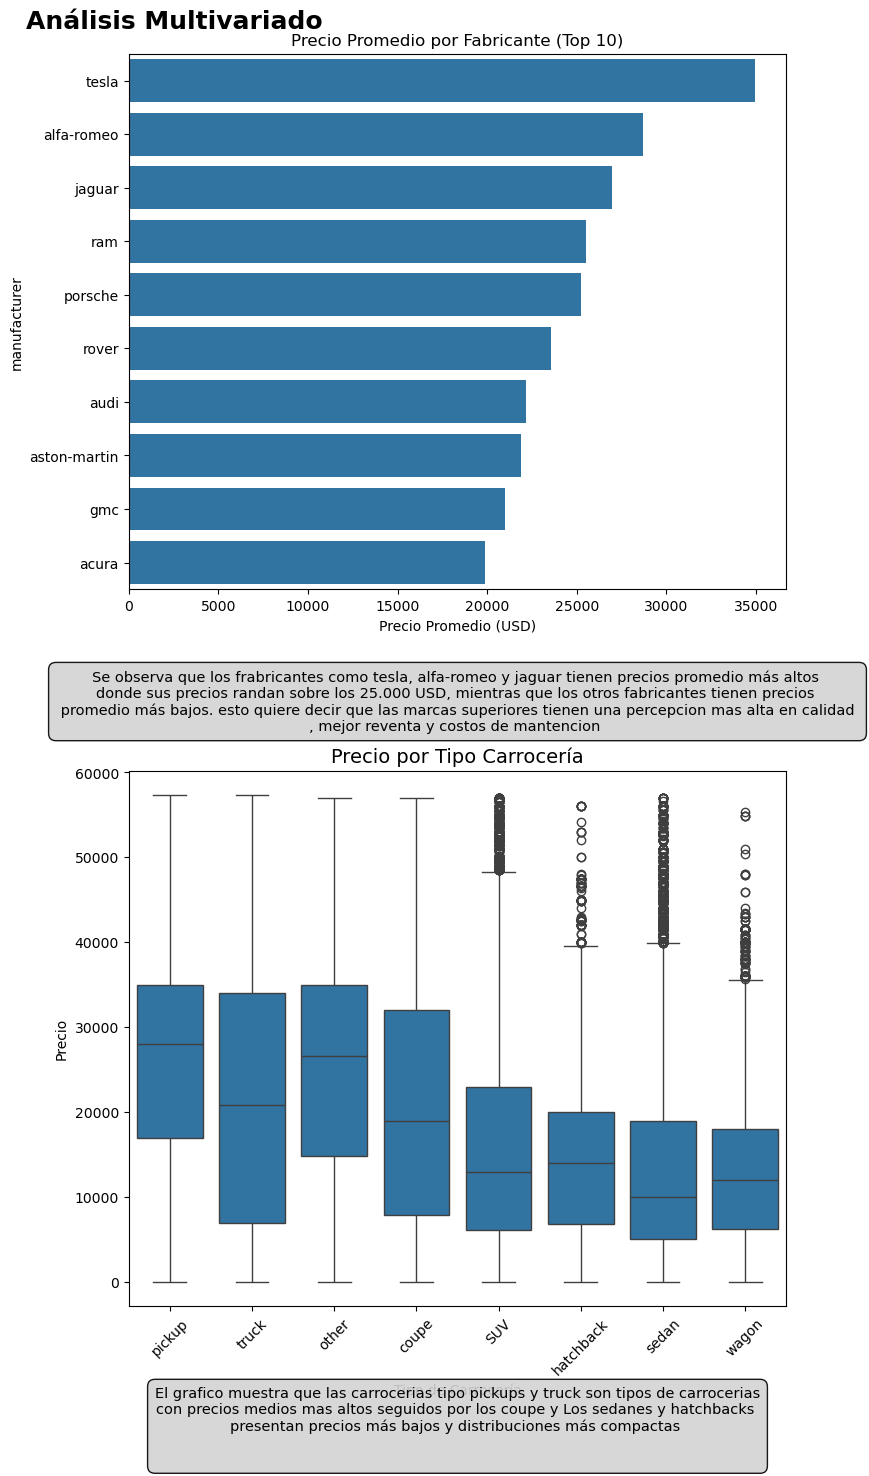

In [13]:
fig2 = plt.figure(figsize=(16, 15))
fig2.suptitle('Análisis Multivariado', fontsize=18, fontweight='bold' , x=0.02,  ha='left')



# . Precio promedio por Fabricante (Top 10)
ax3 = plt.subplot(2, 2,1)
top_manuf = df_2.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_manuf.values, y=top_manuf.index, ax=ax3)
ax3.set_title('Precio Promedio por Fabricante (Top 10)')
ax3.set_xlabel('Precio Promedio (USD)')
ax3.text(0.5, -0.15, 
        'Se observa que los frabricantes como tesla, alfa-romeo y jaguar tienen precios promedio más altos \n'
        'donde sus precios randan sobre los 25.000 USD, mientras que los otros fabricantes tienen precios \n ' 
        'promedio más bajos. esto quiere decir que las marcas superiores tienen una percepcion mas alta en calidad \n'
         ', mejor reventa y costos de mantencion ',
         transform=ax3.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))



# Precio por Carrocería
df_plot = df_2[df_2['type'] != 'desconocido']                    #
top_types = df_plot['type'].value_counts().head(8)

ax4 = plt.subplot(2, 2, 3)
sns.boxplot(data=df_2[df_2['type'].isin(top_types.index)], x='type', y='price', ax=ax4)
ax4.set_title('Precio por Tipo Carrocería', fontsize=14)
ax4.set_xlabel('Tipo de Carrocería')
ax4.set_ylabel('Precio')
ax4.tick_params(axis='x', rotation=45)
ax4.text(0.5, -0.15, 
         'El grafico muestra que las carrocerias tipo pickups y truck son tipos de carrocerias\n' 
         'con precios medios mas altos seguidos por los coupe y Los sedanes y hatchbacks \n' 
         'presentan precios más bajos y distribuciones más compactas \n'
         '\n',
         transform=ax4.transAxes, ha='center', va='top', fontsize=10.5, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

plt.tight_layout()
plt.show()



- Calcular estadísticas descriptivas.

In [14]:
display(df_2.describe())


,id,price,year,odometer,lat,long
count,3.868610e+05,386861.000000,386861.000000,386861.000000,386861.000000,386861.000000
mean,7.311468e+09,16585.603956,2012.559301,91736.666638,38.436608,-93.615490
std,4.390150e+06,13178.614102,5.424076,60011.477776,5.220689,16.786830
min,7.301583e+09,0.000000,1995.000000,0.000000,22.549115,-131.923828
25%,7.308070e+09,5980.000000,2009.000000,39734.000000,34.801450,-110.000000
50%,7.312533e+09,13900.000000,2014.000000,88796.000000,39.157362,-87.865100
75%,7.315244e+09,25990.000000,2017.000000,133759.000000,42.334497,-80.640000
max,7.317101e+09,57341.000000,2022.000000,276000.000000,52.716830,-67.143300


### 4. Modelado y Evaluación:



- 4.1.1  Implementar al menos dos modelos de regresión (Linear Regression y Random Forest Regressor).


In [ ]:
# Eliminar filas donde price no se pudo convertir
col_usar = ['price', 'year', 'odometer','manufacturer', 'condition', 'cylinders', 'fuel',
         'transmission', 'drive', 'type']
df_usar = df_2[col_usar].copy()


df_usar = df_usar.dropna(subset=['price'])

# Convertir otras columnas numéricas
df_usar['year'] = pd.to_numeric(df_usar['year'], errors='coerce')
df_usar['odometer'] = pd.to_numeric(df_usar['odometer'], errors='coerce')

# ====================== RESTO DE LIMPIEZA ======================
df_usar = df_usar[(df_usar['price'] > 100) & (df_usar['price'] < 200000)]
df_usar = df_usar[(df_usar['year'] > 1900) & (df_usar['year'] < 2026)]

# Imputar faltantes
df_usar['year'] = df_usar['year'].fillna(df_usar['year'].median())
df_usar['odometer'] = df_usar['odometer'].fillna(df_usar['odometer'].median())

# Categóricas

for col in col_usar:
    df_usar[col] = df_usar[col].fillna('unknown').astype(str).str.lower().str.strip()

# # Feature Engineering
# df_usar['age'] = 2021 - df_usar['year']
# df_usar['odometer_per_year'] = df_usar['odometer'] / df_usar['age'].replace(0, 1)

# Encoding + Escalado
df_usar = pd.get_dummies(df_usar, columns=['manufacturer', 'condition', 'cylinders', 'fuel',
         'transmission', 'drive', 'type'], drop_first=True)

print(f"✅ Datos listos. Shape final: {df.shape}")



# Features y target
df_usar['price'] = pd.to_numeric(df_usar['price'], errors='coerce')
X = df_usar.drop(columns=['price'])
y = df_usar['price']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------- Modelos -------------------

# Escalado de características
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

#  Crear modelo y entrenar
modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
print('✅ Modelo entrenado')
print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')



✅ Datos listos. Shape final: (426880, 26)
✅ Modelo entrenado
Pendientes aprendidas: [ 5432.06 -3376.82    99.99   -54.76   194.22  -166.62  -365.37   -59.44
  -643.7   -610.78  -240.74  -797.79   -77.03  -429.76  -690.01   -84.43
  -138.68  -484.12  -885.88  -114.53   130.71  -326.66  -866.72   -11.29
   347.66   -25.18  -527.04    85.35  -208.18  -255.29  -680.43   -33.56
 -1119.24  -143.47   439.61  -109.06   192.88  -177.34  -553.55   532.04
    17.14  -863.39   -29.26  -532.22  -233.55  -210.14  -221.26   -46.53
  -170.28    79.12  -445.3  -3915.01  -561.8  -2862.   -1481.03 -3294.49
  -460.38  2523.7   -244.97  -443.67  -220.18    27.79   -45.65   451.05
   844.27 -1531.89 -1910.47  -385.6   1133.43  1585.73  2273.75   550.18
   667.19   330.91  1887.65  3026.1   1594.51  2047.17  2392.17   982.15
   674.3 ]
Intercepto:            18,070.78


- Evaluar los modelos utilizando MSE, RMSE, y R^2.


In [43]:
#  Predecir con el set de test
y_pred = modelo.predict(X_test_esc)

# Comparar real vs predicho (primeras 10)
comparacion = pd.DataFrame({
    'Real':     y_test.values[:10].round(0),
    'Predicho': y_pred[:10].round(0),
    'Error':    (y_test.values[:10] - y_pred[:10]).round(0)
})
comparacion

# metricas de evaluacion

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Evaluacion del modelo .")
print(f'MSE: {mse:,.0f} ()')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}')
print(f'R²: {r2:.4f} ({r2*100:.1f}%)')

Evaluacion del modelo .
MSE: 55,013,871 ()
RMSE:7,417
R²: 0.6626 (66.3%)


Seleccionar el mejor modelo basado en las métricas de evaluación.

In [ ]:

print(f'{'Regrecion Lineal':20s} -> R²={r2_score(y_test, y_pred):.4f} ({r2_score(y_test, y_pred)*100:.1f}%), MAE=${mean_absolute_error(y_test, y_pred):.0f}')
arbol = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train)
rf    = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42).fit(X_train, y_train)

for nombre, m in [('Árbol', arbol), ('Random Forest', rf)]:
    pred = m.predict(X_test)
    print(f'{nombre:20s} -> R²={r2_score(y_test, pred):.4f} ({r2_score(y_test, pred)*100:.1f}%),'
          f' MAE=${mean_absolute_error(y_test, pred):.0f}')


print("\n Conclusion : se recomienda el modelo de random forest por su mejor desempeño en este \n" \
"tipo de datos, aunque el modelo de regresión lineal también ofrece una interpretación más \n " \
"directa de los coeficientes y puede ser útil para entender la relación entre las variables. \n")

Regrecion Lineal     -> R²=0.6626 (66.3%), MAE=$5284
Árbol                -> R²=0.7171 (71.7%), MAE=$4578
Random Forest        -> R²=0.8094 (80.9%), MAE=$3526

✅ Conclusion : se recomienda el modelo de random forest por su mejor desempeño en este 
tipo de datos, aunque el modelo de regresión lineal también ofrece una interpretación más 
 directa de los coeficientes y puede ser útil para entender la relación entre las variables. 



### 5. Optimización del Modelo:

- Optimizar el modelo seleccionado utilizando GridSearchCV.

In [60]:
modelos = {
    'Lineal':  make_pipeline(StandardScaler(), LinearRegression()),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla.round(4))

# Tuning del ganador (asumimos RF)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 150], 'max_depth': [10, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')

Benchmark:
RF        0.8871
Lineal    0.6626
dtype: float64

Mejor RF tuned: {'max_depth': None, 'n_estimators': 150}
R² sin tuning: 0.8871
R² con tuning: 0.8876
